# Beyond the Normal Distribution
As we saw last semester, many of the most commonly used statistical techniques are based on assuming that the data can be modelled as a normal distribution. This had the general form

$$
y_{i} \sim \mathcal{N}\left(\mu_{i}, \sigma^{2}\right),
$$

where we typically think of the mean function in terms of the regression equation

$$
\mu_{i} = \beta_{0} + \sum_{j=1}^{k} \beta_{j}x_{ij}
$$

and the variance function as constant. As such, the data are normally distribution *conditional* on the values of the $k$ predictor variables. This is visualised for a simple regression model in [](#fig-simple-linear-3D).


```{figure} images/standard_norm_3D.gif
:label: fig-simple-linear-3D
:alt: Example of the normal probability model for simple linear regression.
:align: center

Example of the normal probability model for simple linear regression.
```


 Here we can most clearly see that the probability model assumes a normal distribution of data *around* the regression line, for every value of the predictor. This is often equivalently expressed as normally distributed *errors* of the form

 $$
 \begin{align*}
    y_{i}        &= \mu_{i} + \epsilon_{i} \\
    \epsilon_{i} &\sim \mathcal{N}\left(0, \sigma^{2}\right).
 \end{align*}
 $$

## When the Normal Linear Model Fails
Although there are many datasets where the above framework is suitable, there are also many cases where the implications of the model above will not be appropriate. For instance, one limitation is that the normal distribution is defined continuously, meaning that all values either side of the regression line have some defined probability value. However, if our outcome variable is *discrete* this will not be accurate and the model will make predictions outside of the limited values of the data.

A similar issue occurs due to the fact that the normal distribution is *symmetric*. This causes issues when our outcome variable has some hard upper- or lower-limit, as the normal probability model will extended beyond those limits. This symmetric form may also be inappropriate for data that is often skewed, such as reaction times.

To see these issues more clearly, consider the example of a *binary* outcome variable that can only take on a value of 0 or 1. [](#fig-binary-linear-3D) shows what would happen if the normal linear model were applied to this type of outcome.


```{figure} images/binary_norm_3D.gif
:label: fig-binary-linear-3D
:alt: Example of the normal probability model applied to a binary outcome variable.
:align: center

Example of the normal probability model applied to a binary outcome variable.
```

The assumptions plots from this model are shown below

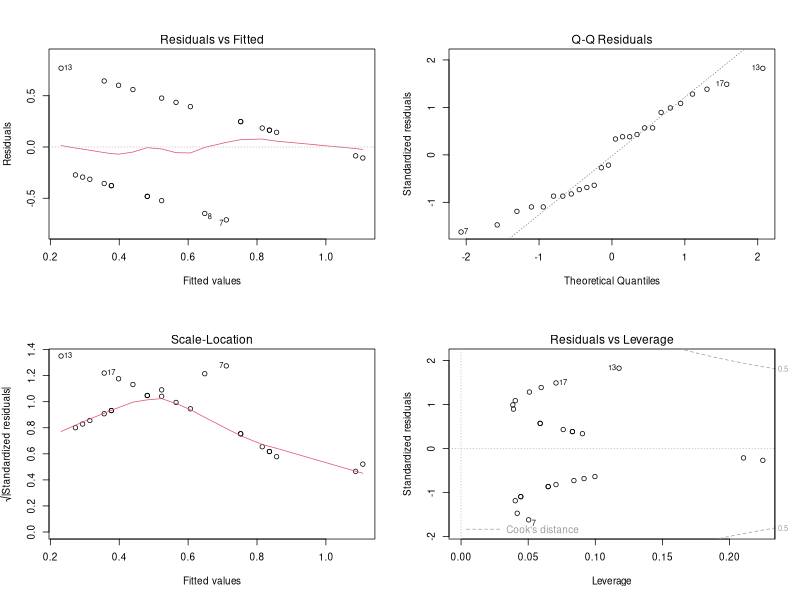

In [2]:
library('faraway')
data(hormone)
par(mfrow=c(2,2))
hormone$orient <- as.numeric(hormone$orientation)
hormone$orient[hormone$orient == 2] <- 0
mod <- lm(as.numeric(orient) ~ estrogen, data=hormone)
plot(mod)
par(mfrow=c(1,1))

What is perhaps surprising is that the Q-Q Residuals plot does not look too concerning here. However, this is really just a consequence of pooling across predictor values. This does not validate the normal-error assumption, which concerns the conditional distribution of the outcome at a given predictor value. For a binary outcome variable, it can never be the case that the data are normally distributed for a given value of the predictor because the outcome can only have two values. Two values cannot be normally distributed. 

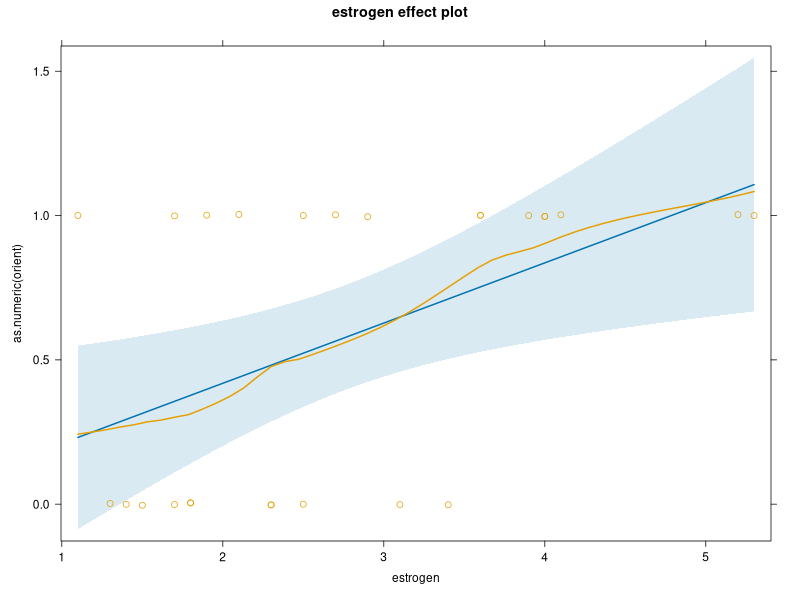

In [3]:
suppressMessages(library(effects))
plot(allEffects(mod, residuals=TRUE))

## Transformations
As we saw last semester, there are options available for transforming data if the assumptions of the linear model are not met. It is sometimes the case that we can take data that is not suitable for modelling with a normal distribution and transform it to become more suitable. However, this approach has some distinct limitations as a transformation will directly impact the interpretability of the model and will not magically turn a discrete variable into a continuous variable. The model itself will also be capable of making predictions beyond the plausible limits of the outcome variable.   

## Alternative Data Types 

### Binary Outcomes
... the Bernoulli distribution.

### Proportional Outcomes 
... the Binomial distribution

### Count Outcomes
... the Poisson distribution and Negative Binomial distributions ...

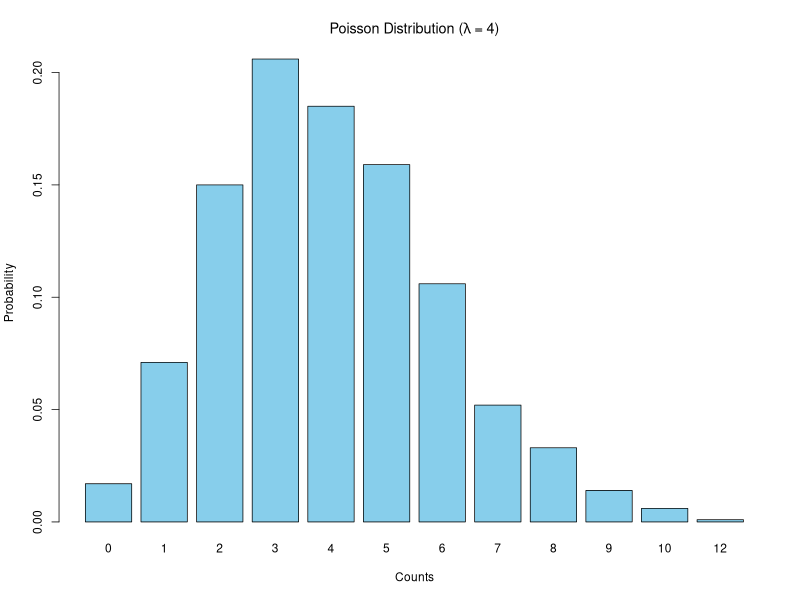

In [4]:
set.seed(123)
y <- rpois(n=1000, lambda=4)
barplot(table(y)/1000,
        col='skyblue',
        xlab="Counts", 
        ylab="Probability", 
        main=expression(paste("Poisson Distribution (", lambda, " = 4)")))

### Skewed Continuous Outcomes
... Reaction time data is an obvious example
... The Gamma distribution and Inverse Gaussian distributions ...

## Parameterisation of Alternative Distributions
... For example, the $\lambda$ parameter of the Poisson distribution is easily interpretable as the average count. However, this parameter also controls the variance of the Poisson distribution as well. As such, it is not possible to independently adjust the centre of the distribution and its width. 

As another example, the Gamma distribution is parameterised by both a *shape* and a *scale* parameter, that may not necessarily be intuitive on their own.

In part, these additional difficulties illustrate why the Gaussian distribution is so often used. It has a simple and intuitive parameterisation with values that are directly interpretable. In addition, the mean and variance are independent and can be adjusted separately. However, once we have data that is no longer suitable for modelling with a normal distribution, we must consider these alternatives.